# Section 1: Load the data and EDA #

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the telco1 dataset
telco_df = pd.read_csv('telco1.csv')

# Check the basic info of the dataframe
telco_df.info()
telco_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Check the basic info of the features
telco_df["TotalCharges"] = pd.to_numeric(telco_df["TotalCharges"], errors="coerce")
for col in telco_df.columns:
    print(f"--- {col} ---")
    print(f"  dtype     : {telco_df[col].dtype}")
    print(f"  missing   : {telco_df[col].isnull().sum()}")
    print(f"  unique    : {telco_df[col].nunique()}")
    print(f"  sample    : {telco_df[col].unique()[:5]}")
    print()

--- customerID ---
  dtype     : object
  missing   : 0
  unique    : 7043
  sample    : ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU']

--- gender ---
  dtype     : object
  missing   : 0
  unique    : 2
  sample    : ['Female' 'Male']

--- SeniorCitizen ---
  dtype     : int64
  missing   : 0
  unique    : 2
  sample    : [0 1]

--- Partner ---
  dtype     : object
  missing   : 0
  unique    : 2
  sample    : ['Yes' 'No']

--- Dependents ---
  dtype     : object
  missing   : 0
  unique    : 2
  sample    : ['No' 'Yes']

--- tenure ---
  dtype     : int64
  missing   : 0
  unique    : 73
  sample    : [ 1 34  2 45  8]

--- PhoneService ---
  dtype     : object
  missing   : 0
  unique    : 2
  sample    : ['No' 'Yes']

--- MultipleLines ---
  dtype     : object
  missing   : 0
  unique    : 3
  sample    : ['No phone service' 'No' 'Yes']

--- InternetService ---
  dtype     : object
  missing   : 0
  unique    : 3
  sample    : ['DSL' 'Fiber optic' 'No']

--- Onl

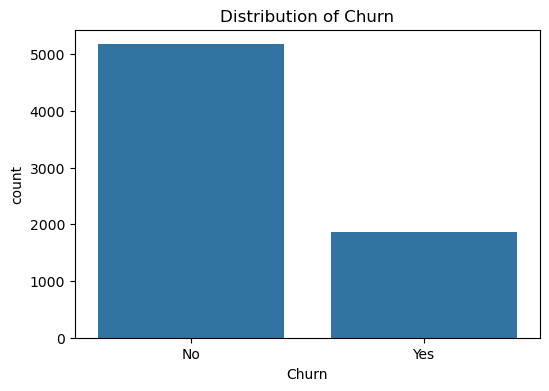

In [3]:
# EDA
# Distribution of the target variable 'Churn'
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=telco_df)
plt.title('Distribution of Churn')
plt.show()

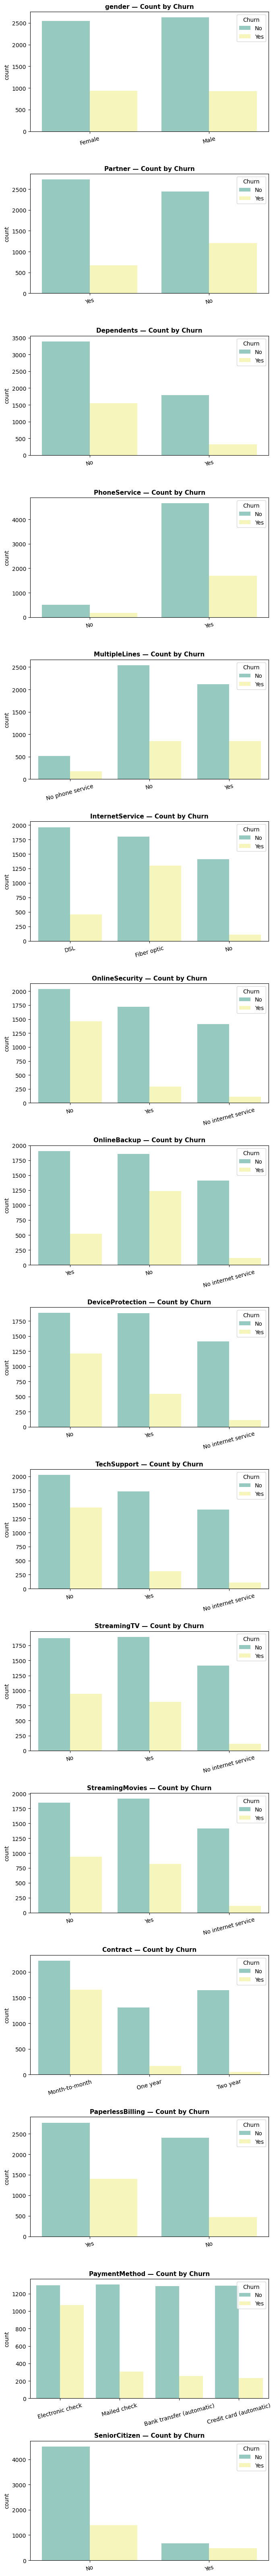

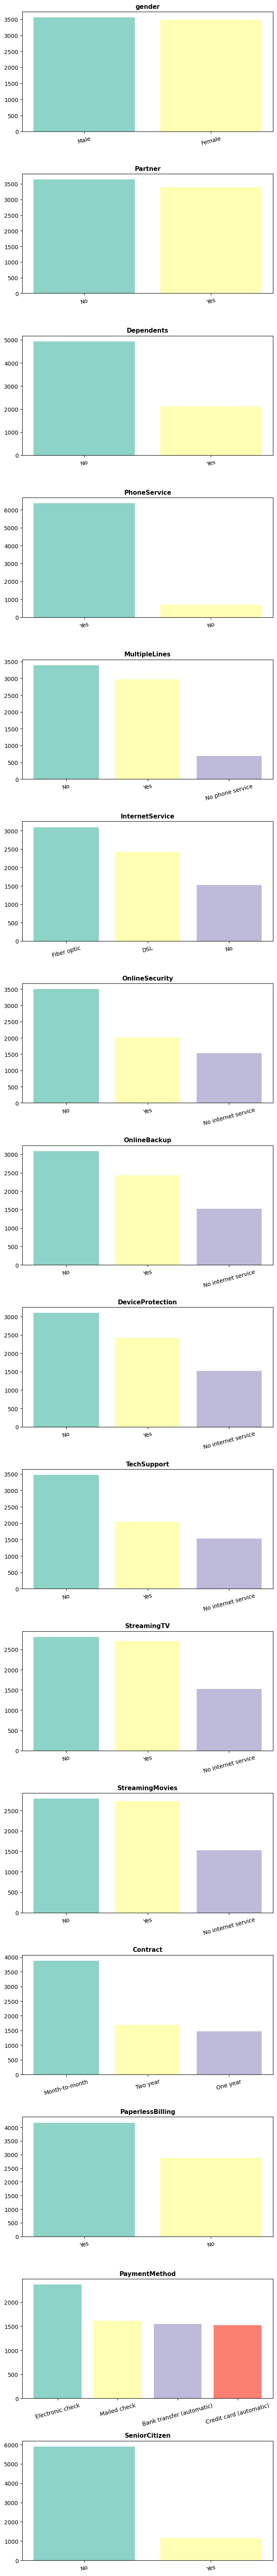

In [4]:
# EDA
# Manually classify the features into categorical and numerical
categorical_cols = [
    "gender", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod", "SeniorCitizen"
]

# Copy the dataframe for EDA plot
df_plot = telco_df.copy()
df_plot["SeniorCitizen"] = df_plot["SeniorCitizen"].map({0: "No", 1: "Yes"})

# Plots for categorical features vs churn
fig, axes = plt.subplots(len(categorical_cols), 1 , figsize=(7, len(categorical_cols) * 4))

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df_plot, x=col, hue="Churn", palette="Set3", ax=axes[i])
    axes[i].set_title(f"{col} — Count by Churn", fontsize=11, weight="bold")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# Plots for categorical features distribution
fig, axes = plt.subplots(len(categorical_cols), 1 , figsize=(7, len(categorical_cols) * 4))
for i, col in enumerate(categorical_cols):
    value_counts = df_plot[col].value_counts(dropna=False)
    colors = sns.color_palette("Set3", len(value_counts))
    axes[i].bar(value_counts.index.astype(str), value_counts.values, color=colors)
    axes[i].set_title(f"{col}", fontsize=11, weight="bold")
    axes[i].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

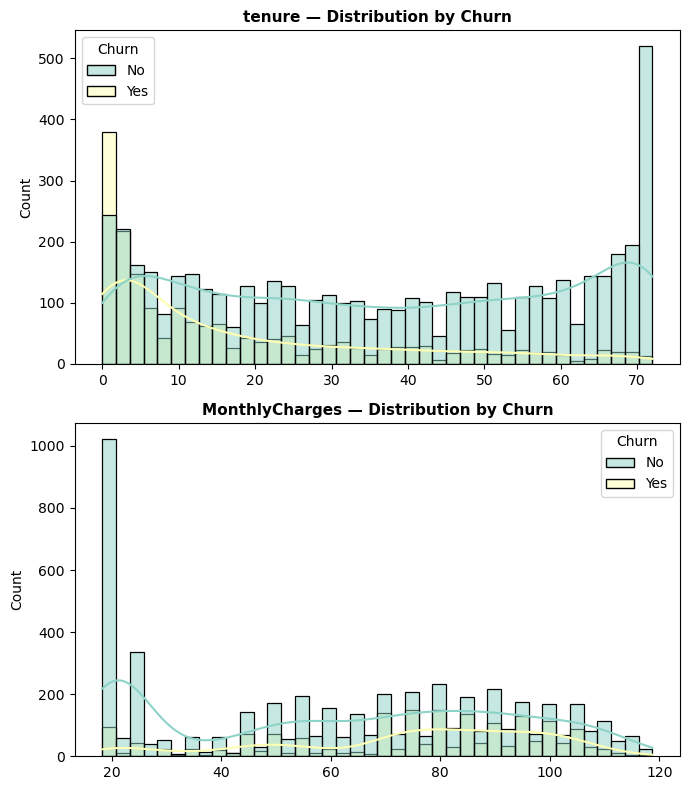

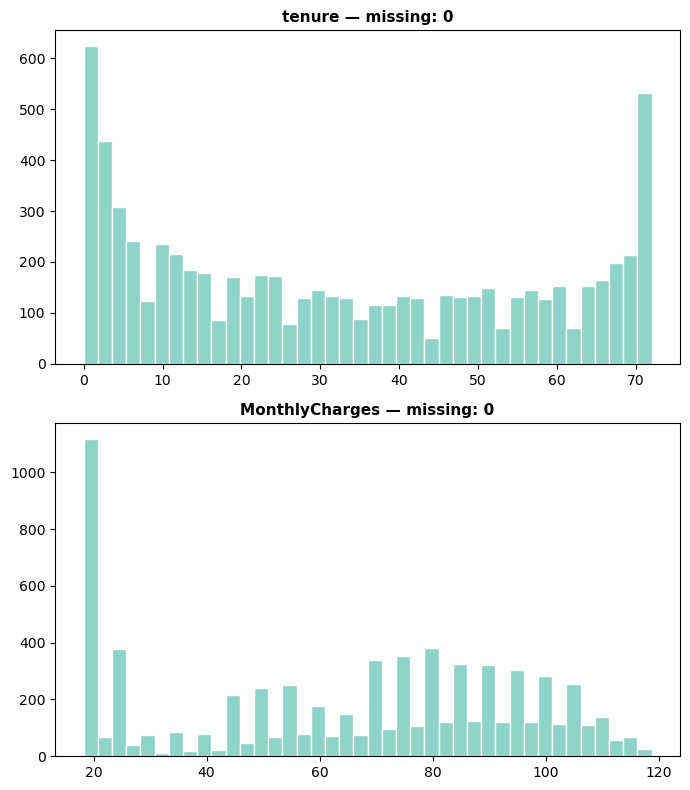

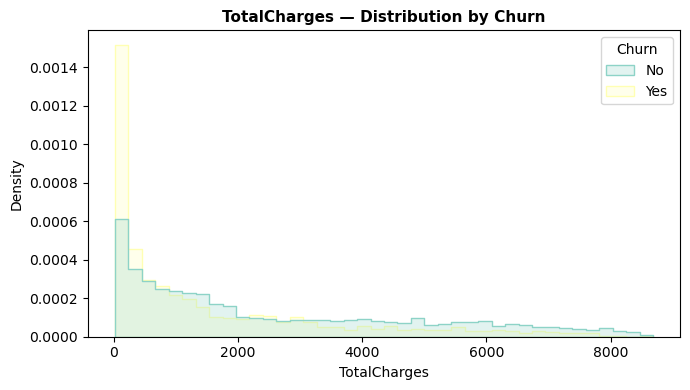

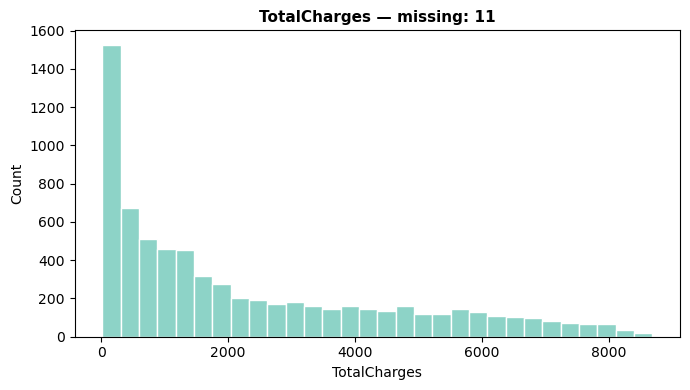

In [5]:
# # TotalCharges is skewed with a wide range (0–8000+), so it is plotted separately for clarity
numeric_cols = [
    "tenure", "MonthlyCharges"
]
# Plots for numeric features vs churn
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(7, len(numeric_cols) * 4))

for i, col in enumerate(numeric_cols):
    bins = 30 if pd.to_numeric(df_plot[col], errors='coerce').max() > 1000 else 40
    sns.histplot(data=df_plot, x=col, hue="Churn", bins=bins, kde=True,
                 palette="Set3", ax=axes[i])
    axes[i].set_title(f"{col} — Distribution by Churn", fontsize=11, weight="bold")
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

# Plots for numeric features distribution
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(7, len(numeric_cols) * 4))

for i, col in enumerate(numeric_cols):
    bins = 30 if pd.to_numeric(df_plot[col], errors='coerce').max() > 1000 else 40
    axes[i].hist(df_plot[col].dropna(), bins=bins,
                 color=sns.color_palette("Set3")[0], edgecolor="white")
    axes[i].set_title(f"{col} — missing: {df_plot[col].isnull().sum()}", fontsize=11, weight="bold")
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# make sure TotalCharges is numeric
df_plot["TotalCharges"] = pd.to_numeric(df_plot["TotalCharges"], errors="coerce")

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(
    data=df_plot,
    x="TotalCharges",
    hue="Churn",
    bins=40,
    kde=False,
    stat="density",
    common_norm=False,
    element="step",
    palette="Set3",
    ax=ax
)
ax.set_title("TotalCharges — Distribution by Churn", fontsize=11, weight="bold")
ax.set_xlabel("TotalCharges")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

# TotalCharges overall distribution
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    df_plot["TotalCharges"].dropna(),
    bins=30,
    color=sns.color_palette("Set3")[0],
    edgecolor="white"
)
ax.set_title(
    f"TotalCharges — missing: {df_plot['TotalCharges'].isnull().sum()}",
    fontsize=11,
    weight="bold"
)
ax.set_xlabel("TotalCharges")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# Secton 2: Preprocess #

In [6]:
# Define X and y
customer_ids = telco_df["customerID"]
X = telco_df.drop(columns=["customerID", "Churn"]) # customerID is a unique identifier for each customer and carries no predictive information. There's no repitition so we can assume IID.
y = telco_df["Churn"].map({"Yes": 1, "No": 0})

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [7]:
# Split the data into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=42, stratify=y)

test_ids = customer_ids.iloc[X_test.index].values
train_ids = customer_ids.iloc[X_train.index].values

In [8]:
# Reclassify the features into categorical and numerical for preprocessing
categorical_cols = [
    "gender", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod", "SeniorCitizen"
]
numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Create the encoding pipelines for categorical and numerical features
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Categorical
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Numerical
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),#I didn't use MICE here cause the missing values are small.
    ("scaler", StandardScaler())
])

# Wrap them into a ColumnTransformer
preprocess = ColumnTransformer([
    ("cat", categorical_pipeline, categorical_cols),
    ("num", numerical_pipeline, numerical_cols)
])

# Section 3: Hyperparameter training #

In [9]:
# Logistic Regression Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

lr_pipeline = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=1000, random_state=42, solver="saga", class_weight="balanced"))
])

param_grid_lr = {
    "model__C": [0.01, 0.01, 0.1, 1, 10, 100],
     "model__penalty": ["l1","l2"]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid_lr,
    cv=10,
    scoring="roc_auc",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("Best params:", lr_grid.best_params_)
print("Best CV AUC:", lr_grid.best_score_)

Best params: {'model__C': 10, 'model__penalty': 'l2'}
Best CV AUC: 0.8445990009296107


In [10]:
# XGboost Pipeline
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipeline = Pipeline([
    ("prep", preprocess),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    ))
])

param_grid_xgb = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 5, 7, 9, 11],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=10,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print("Best params:", xgb_grid.best_params_)
print("Best CV AUC:", xgb_grid.best_score_)

Fitting 10 folds for each of 80 candidates, totalling 800 fits
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 500}
Best CV AUC: 0.8466989419149981


# Section 4: Train the models

In [11]:
# Logistic Regression
from sklearn.metrics import roc_auc_score, classification_report

best_lr = lr_grid.best_estimator_
best_lr.fit(X_train, y_train)

y_pred_lr = best_lr.predict(X_test)
y_pred_proba_lr = best_lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Test AUC:", roc_auc_score(y_test, y_pred_proba_lr).round(4))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Test AUC: 0.8454
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1294
           1       0.52      0.79      0.63       467

    accuracy                           0.75      1761
   macro avg       0.71      0.76      0.72      1761
weighted avg       0.80      0.75      0.76      1761



In [12]:
# Xgboost
best_xgb = xgb_grid.best_estimator_
best_xgb.fit(X_train, y_train)
y_pred_xgb = best_xgb.predict(X_test)
y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
print("XGBoost Test AUC:", roc_auc_score(y_test, y_pred_proba_xgb).round(4))
print(classification_report(y_test, y_pred_xgb))

XGBoost Test AUC: 0.8476
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1294
           1       0.52      0.81      0.63       467

    accuracy                           0.75      1761
   macro avg       0.72      0.77      0.72      1761
weighted avg       0.81      0.75      0.76      1761



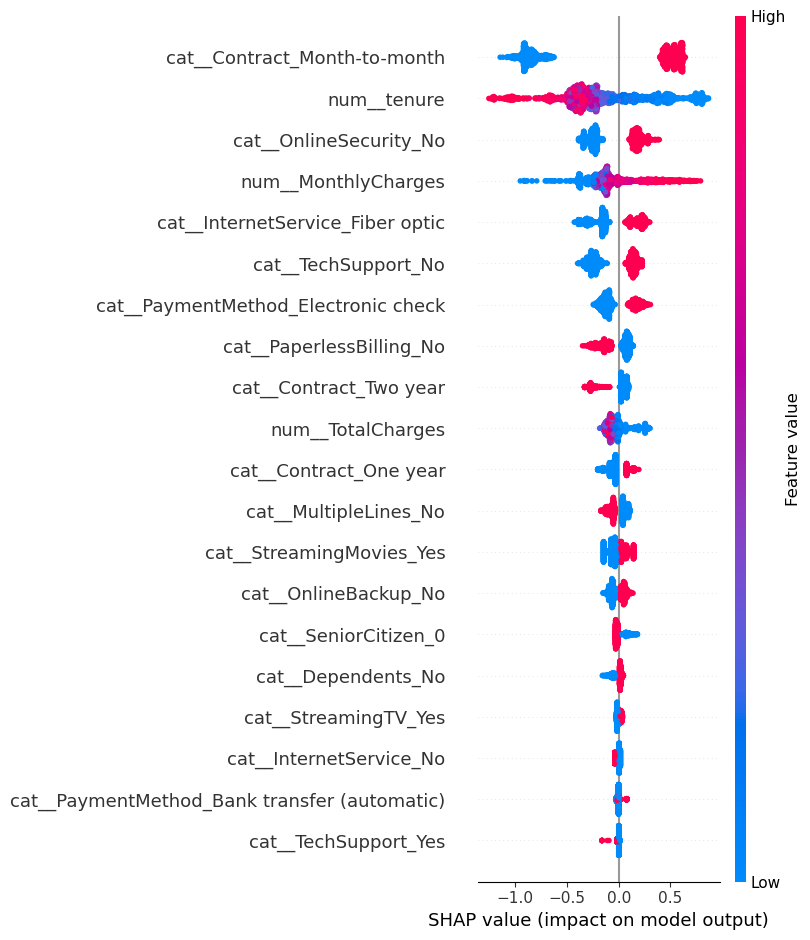

In [13]:
!pip install shap
import shap

xgb_model = best_xgb.named_steps["model"]
X_test_transformed = best_xgb.named_steps["prep"].transform(X_test)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)


feature_names = best_xgb.named_steps["prep"].get_feature_names_out()

shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

# Section 5: Append predicted probabilities

In [14]:
# Append predicted probability to train and test (I use the xgb predicted probability since it has slightly better performance)

# Train
train_df = X_train.copy()
train_df["Churn_Actual"] = y_train.values
train_df["Churn_Proba"] = best_xgb.predict_proba(X_train)[:, 1]

# Test
test_df = X_test.copy()
test_df["Churn_Actual"] = y_test.values
test_df["Churn_Proba"] = y_pred_proba_xgb

test_df["customerID"] = test_ids
train_df["customerID"] = train_ids

print("Train set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

train_df.head()
test_df.head()

Train set shape: (5282, 22)
Test set shape: (1761, 22)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Actual,Churn_Proba,customerID
5909,Female,0,No,No,52,Yes,Yes,Fiber optic,No,Yes,...,No,No,One year,Yes,Mailed check,80.20,4297.6,0,0.258884,5343-SGUBI
3670,Female,0,Yes,Yes,33,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),24.25,838.5,0,0.215525,5442-BXVND
6220,Male,0,Yes,Yes,10,No,No phone service,DSL,Yes,Yes,...,No,Yes,Two year,No,Credit card (automatic),53.70,521.0,0,0.081821,6434-TTGJP
5905,Male,0,No,No,1,Yes,No,Fiber optic,No,Yes,...,No,Yes,Month-to-month,Yes,Electronic check,85.00,85.0,0,0.924952,1628-BIZYP
6435,Male,0,Yes,Yes,52,No,No phone service,DSL,No,Yes,...,Yes,No,Two year,No,Mailed check,50.20,2554.0,0,0.081044,0298-XACET


# Section 6: 3 Risk Groups

In [15]:
def assign_risk(prob):
    if prob > 0.65:
        return "High"
    elif prob >= 0.35:
        return "Mid"
    else:
        return "Low"

test_df["Risk_Group"] = test_df["Churn_Proba"].apply(assign_risk)

test_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Actual,Churn_Proba,customerID,Risk_Group
5909,Female,0,No,No,52,Yes,Yes,Fiber optic,No,Yes,...,No,One year,Yes,Mailed check,80.20,4297.6,0,0.258884,5343-SGUBI,Low
3670,Female,0,Yes,Yes,33,Yes,Yes,No,No internet service,No internet service,...,No internet service,Month-to-month,No,Bank transfer (automatic),24.25,838.5,0,0.215525,5442-BXVND,Low
6220,Male,0,Yes,Yes,10,No,No phone service,DSL,Yes,Yes,...,Yes,Two year,No,Credit card (automatic),53.70,521.0,0,0.081821,6434-TTGJP,Low
5905,Male,0,No,No,1,Yes,No,Fiber optic,No,Yes,...,Yes,Month-to-month,Yes,Electronic check,85.00,85.0,0,0.924952,1628-BIZYP,High
6435,Male,0,Yes,Yes,52,No,No phone service,DSL,No,Yes,...,No,Two year,No,Mailed check,50.20,2554.0,0,0.081044,0298-XACET,Low


# Section 7: AI agent
** To run this notebook, create a `.env` file in the same directory with:
OPENAI_API_KEY=your_api_key **

In [16]:
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
print("Key loaded:", api_key[:10], "...")

Key loaded: sk-proj-DC ...


In [17]:
!pip install openai
from openai import OpenAI

client = OpenAI(api_key=api_key)

def ask_agent(question, context):
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {
                "role": "system",
                "content": "You are a data analyst expert in telecom customer churn analysis."
            },
            {
                "role": "user",
                "content": f"Here is the customer data:\n{context}\n\nQuestion: {question}"
            }
        ]
    )
    return response.choices[0].message.content

In [18]:
# Q1: Pick a customer with Churn=YES and probability>0.65 in high risk group
q1_customer = test_df[
    (test_df["Churn_Actual"] == 1) & 
    (test_df["Churn_Proba"] > 0.65) & 
    (test_df["Risk_Group"] == "High")
].iloc[0]

question_q1 = "Give me the top three reasons why this customer churns to other carriers?"
context_q1 = q1_customer.to_string()

answer_q1 = ask_agent(question_q1, context_q1)
print("Q1:", answer_q1)

Q1: Based on the customer data provided, the top three reasons why this customer might be likely to churn to other carriers are:

1. **Month-to-Month Contract:** The customer is on a month-to-month contract, which offers the flexibility to switch carriers at any time without incurring penalties. This often correlates with higher churn rates because customers do not have long-term commitments that might discourage them from leaving.

2. **High Monthly Charges:** With a monthly charge of $96.4, this customer may perceive the cost as higher than average, especially when compared to alternatives. Customers who find their charges excessive relative to their perceived value are more inclined to churn.

3. **Lack of Additional Services:** The customer is not subscribed to several value-added services such as Online Security, Online Backup, Device Protection, and Tech Support. The absence of these services can reduce perceived value and satisfaction, making the customer more vulnerable to offe

In [19]:
# Q2: Pick a customer with Churn=NO and probability<0.3 in low risk group
q2_customer = test_df[
    (test_df["Churn_Actual"] == 0) & 
    (test_df["Churn_Proba"] < 0.3) & 
    (test_df["Risk_Group"] == "Low")
].iloc[0]

context_q2 = q2_customer.to_string()
question_q2 = "Give me the top three reasons why this customer DOES NOT churn."

answer_q2 = ask_agent(question_q2, context_q2)
print(answer_q2)

Based on the provided customer data, here are the top three reasons why the customer likely does not churn:

1. **Contract Type: One Year**
   - Customers with longer contract commitments, such as a one-year contract, are less likely to churn compared to those with month-to-month contracts. This customer is likely committed to staying with the service provider for the contract period, which reduces churn probability.

2. **Tenure: 52 Months**
   - The customer has been with the service provider for 52 months, indicating a long-term relationship. Customers with longer tenures tend to have higher satisfaction and loyalty levels, making them less likely to churn.

3. **Low Churn Probability: 0.258884**
   - The churn probability for this customer is relatively low at approximately 25.9%. This suggests that, statistically, there is a high likelihood that this customer will remain with the service provider based on the factors considered in the churn model, such as tenure, contract type, an

In [20]:
# Q3: Describe the dataset
context_q3 = f"""
Dataset shape: {test_df.shape}
Columns: {test_df.columns.tolist()}
Churn rate: {test_df['Churn_Actual'].mean():.1%}
Numeric summary:
{test_df[numeric_cols].describe().to_string()}
"""

question_q3 = "Describe this telecom dataset."

answer_q3 = ask_agent(question_q3, context_q3)
print(answer_q3)

This telecom dataset provides a comprehensive view of customer data and related metrics for churn analysis. It contains 1,761 entries (customers) and 23 columns, each representing a different attribute or metric of the customer's account or service usage. Here's a breakdown of the columns and key statistics:

1. **Demographic and Account Information:**
   - `customerID`: Unique identifier for each customer.
   - `gender`: Male or Female.
   - `SeniorCitizen`: Indicates if the customer is a senior citizen (1) or not (0).
   - `Partner`: Indicates if the customer has a partner (Yes or No).
   - `Dependents`: Indicates if the customer has dependents (Yes or No).

2. **Service and Usage Information:**
   - `tenure`: Number of months the customer has stayed with the company.
     - **Summary statistics** show a mean tenure of approximately 32 months, with a minimum of 0 and a maximum of 72.
   - `PhoneService`: Indicates if the customer has a phone service (Yes or No).
   - `MultipleLines`:

In [21]:
# Q4: Overall profile of high risk group
high_risk = test_df[test_df["Risk_Group"] == "High"]

context_q4 = f"""
High risk group size: {len(high_risk)}
Churn rate in high risk group: {high_risk['Churn_Actual'].mean():.1%}
Numeric summary:
{high_risk[numeric_cols].describe().to_string()}
"""

question_q4 = "What are the overall profiles of customers in the high risk group?"

answer_q4 = ask_agent(question_q4, context_q4)
print(answer_q4)

Based on the provided customer data for the high-risk group, the overall profiles of these customers can be summarized as follows:

1. **Churn Rate:**
   - The churn rate in the high-risk group is 60.5%, indicating that a significant portion of these customers are likely to stop using the service.

2. **Tenure:**
   - The average tenure of customers in this group is approximately 12.18 months.
   - The tenure distribution suggests that many customers are relatively new, with 25% having a tenure of 2 months or less.
   - Half of the customers have tenures up to 7 months, and 75% have tenures up to 18.25 months.
   - The maximum tenure observed is 63 months, showing that there are a few long-term customers as well.

3. **Monthly Charges:**
   - The average monthly charge for this group is approximately $78.35.
   - Customers in the 25th percentile have monthly charges of about $70.29 or less, indicating that a quarter of this group pays relatively lower charges.
   - The median monthly c

In [22]:
# Q5: Overall profile of low risk group
low_risk = test_df[test_df["Risk_Group"] == "Low"]

context_q5 = f"""
Low risk group size: {len(low_risk)}
Churn rate in low risk group: {low_risk['Churn_Actual'].mean():.1%}
Numeric summary:
{low_risk[numeric_cols].describe().to_string()}
"""

question_q5 = "What are the overall profiles of customers in the low risk group?"

answer_q5 = ask_agent(question_q5, context_q5)
print(answer_q5)

The low risk group comprises 834 customers characterized by a notably low churn rate of 5.6%. The key aspects of these customers' profiles can be summarized from the numerical data provided:

1. **Tenure**: 
   - **Mean tenure**: Approximately 45.8 months, indicating these customers have been with the telecom provider for a long period.
   - **Distribution**:
     - 25% of customers have a tenure of at least 28 months.
     - 50% (median) have been with the company for 50 months.
     - 75% have a tenure of up to 66 months.
   - The maximum tenure reported is 72 months, suggesting that some customers in this group have been with the provider nearly from inception of some plans.

2. **Monthly Charges**:
   - **Mean monthly charges**: About $53.47, indicating a moderate spending range compared to typical telecom billing.
   - **Distribution**:
     - 25% of customers pay $20.41 or more.
     - 50% (median) have monthly charges of $54.23.
     - 75% have monthly charges up to $79.95.
   -

In [23]:
# Q6: Pick a customer by customerID in high risk group with Churn=YES and probability>0.7
q6_customer = test_df[
    (test_df["Churn_Actual"] == 1) & 
    (test_df["Churn_Proba"] > 0.7) & 
    (test_df["Risk_Group"] == "High")
].iloc[0]

print("Customer ID:", q6_customer["customerID"])

context_q6 = q6_customer.to_string()
question_q6 = f"Customer ID {q6_customer['customerID']}: What are the top 3 reasons/factors that drive this customer to churn?"

answer_q6 = ask_agent(question_q6, context_q6)
print(answer_q6)

Customer ID: 8245-UMPYT
Based on the data provided for the customer with ID 8245-UMPYT, here are the top 3 factors that likely drive this customer to churn:

1. **Contract Type - Month-to-Month**: Customers with a month-to-month contract are more flexible in leaving the service compared to those with a longer-term contract (like annual contracts). This flexibility can contribute significantly to higher churn rates.

2. **Internet Service Type - Fiber Optic with No Additional Services**: The customer is using fiber optic internet but has not opted for additional services such as OnlineSecurity, OnlineBackup, DeviceProtection, or TechSupport. The lack of bundled services could make it easier for the customer to switch providers, as there is less of a perceived loss in service features.

3. **Monthly Charges - High Cost**: With monthly charges of $96.4, the cost is relatively high, which might contribute to customer dissatisfaction, especially if they do not perceive value for money, give